## Problem Statement

Develop a machine learning model that predicts an individual's annual medical insurance charges based on demographic and lifestyle factors such as age, BMI, smoking status, gender, number of children, and region. The objective is to help insurance companies estimate premiums more accurately and assist customers in understanding the factors influencing healthcare costs.

# OverView

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset = pd.read_csv("/home/demon/Desktop/CSE/ML/Projects/insurance-premium-prediction/data/raw/insurance.csv")

In [3]:
dataset.head()   

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [5]:
dataset.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [6]:
dataset.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [7]:
dataset.duplicated().sum()

np.int64(1)

In [8]:
dataset = dataset.drop_duplicates()

# Identify feature types

In [9]:
target = "charges"

X=dataset.drop('charges',axis=1)
Y=dataset[target]

In [10]:
cat_features = X.select_dtypes(include=["object", "string"]).columns.tolist()
num_features = X.select_dtypes(include=["number"]).columns.tolist()

print("Categorical:", cat_features)
print("Numerical:", num_features)

Categorical: ['sex', 'smoker', 'region']
Numerical: ['age', 'bmi', 'children']


# EDA

Distribution of Numerical Features

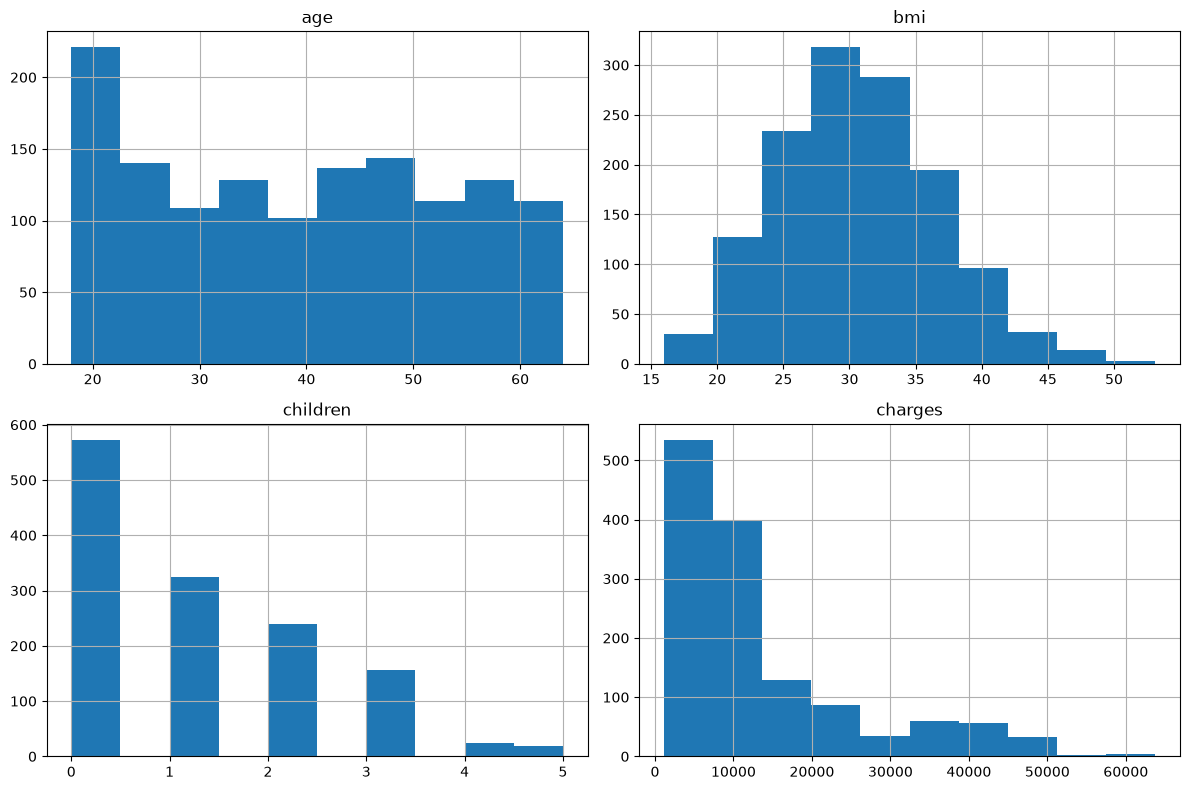

In [11]:
dataset.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

Distribution of Categorical Features

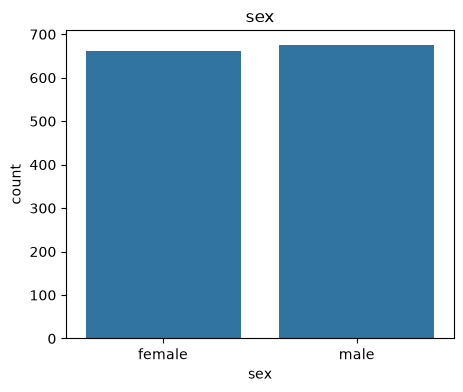

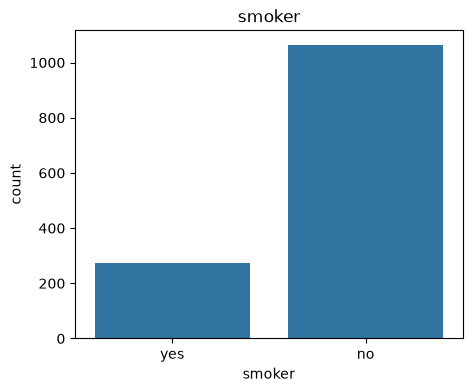

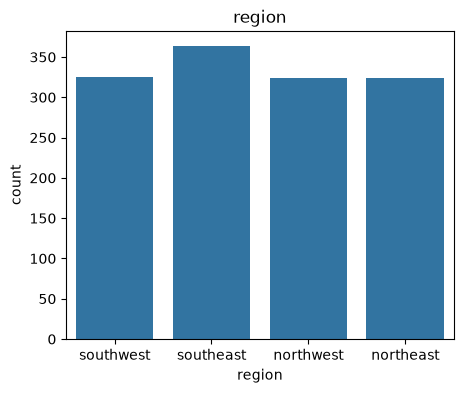

In [12]:
for col in cat_features:
    plt.figure(figsize=(5,4))
    sns.countplot(data=dataset, x=col)
    plt.title(col)
    plt.show()

Correlation Heatmap

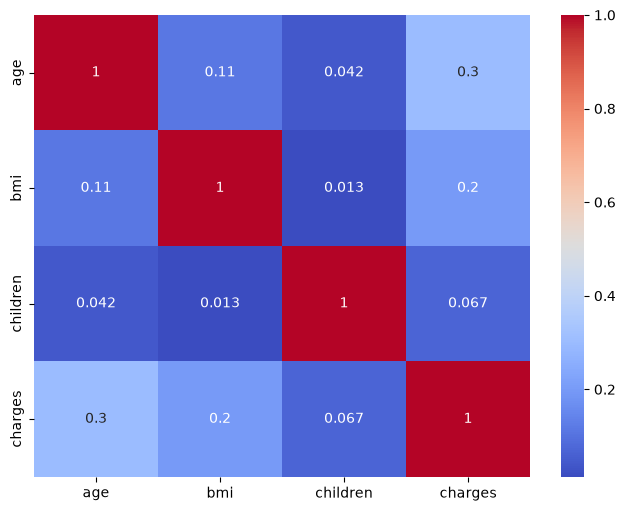

In [13]:
plt.figure(figsize=(8,6))
sns.heatmap(dataset.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")
plt.show()

Outlier Detection

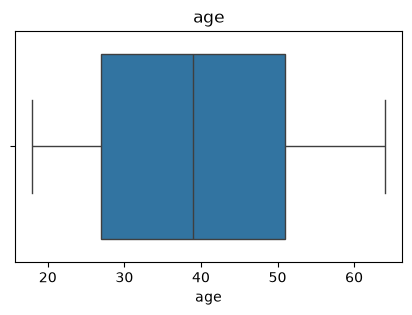

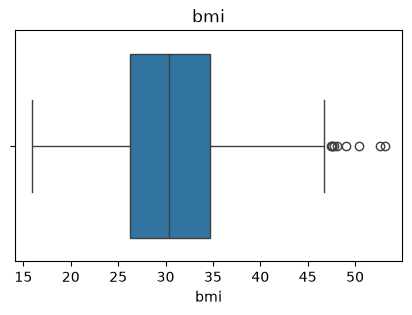

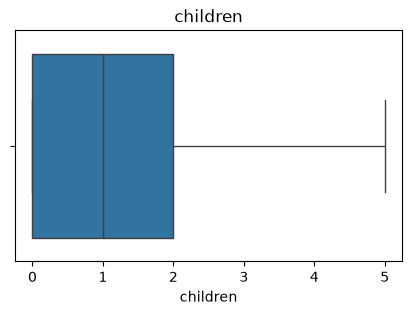

In [14]:
for col in num_features:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=dataset[col])
    plt.title(col)
    plt.show()

Charges Distribution

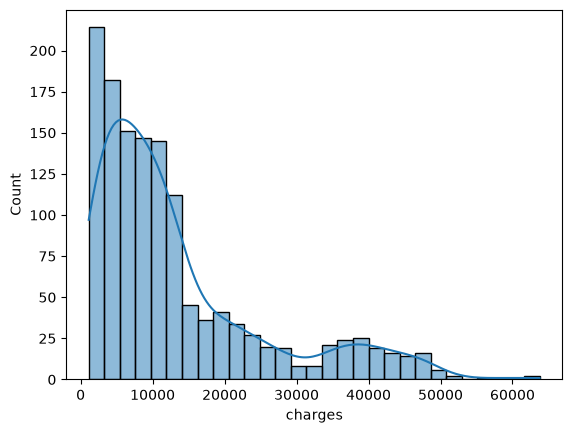

In [15]:
sns.histplot(dataset["charges"], kde=True)
plt.show()

Relationship with Target

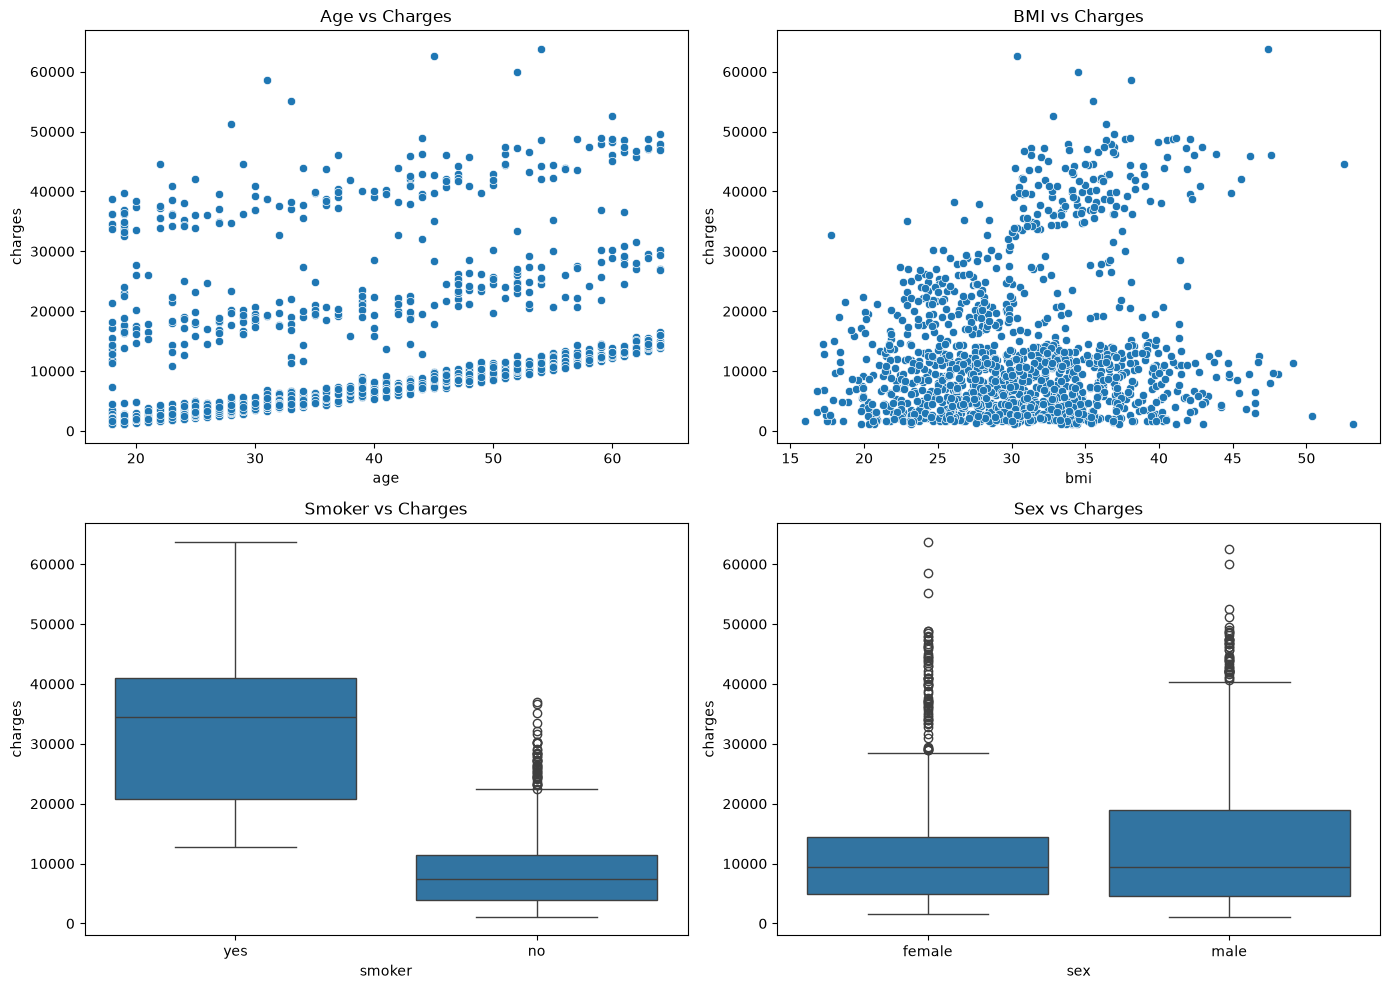

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.scatterplot(data=dataset, x="age", y="charges", ax=axes[0,0])
axes[0,0].set_title("Age vs Charges")

sns.scatterplot(data=dataset, x="bmi", y="charges", ax=axes[0,1])
axes[0,1].set_title("BMI vs Charges")

sns.boxplot(data=dataset, x="smoker", y="charges", ax=axes[1,0])
axes[1,0].set_title("Smoker vs Charges")

sns.boxplot(data=dataset, x="sex", y="charges", ax=axes[1,1])
axes[1,1].set_title("Sex vs Charges")

plt.tight_layout()
plt.show()